# Stability of Rankings LIME vs SHAP
This notebook will try and investigate the differences in the stability of the rankings produced by the two methods

In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult_imbalanced", "old_adult"],
    "../data/",
)

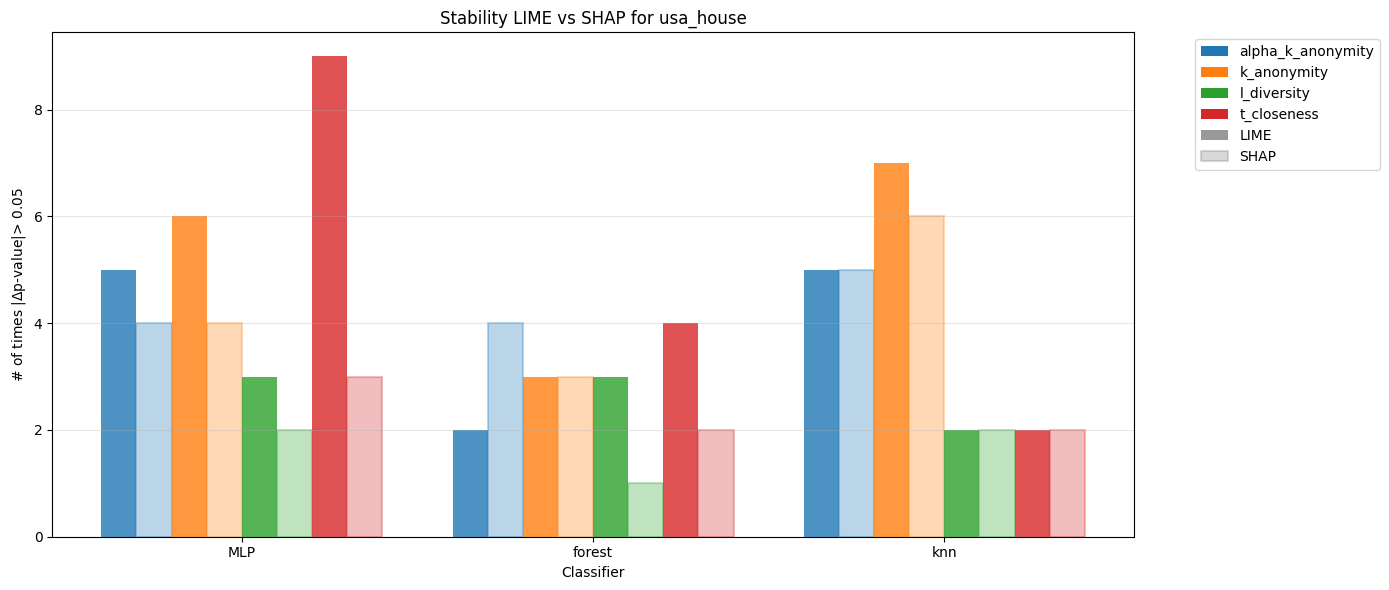

In [10]:
pl.plot_histogram("usa_house", threshold=0.05)

This shows that LIME produces rankings that tend to to change more times. Note, here we are looking at the amount of times the pvalue changes with more than 0.05. 5% has been chosen becaue it is often used in the litterature for significance measuring. If there is a p-value of 0, such a change would make the correlation not significant.  
Consider the next plot

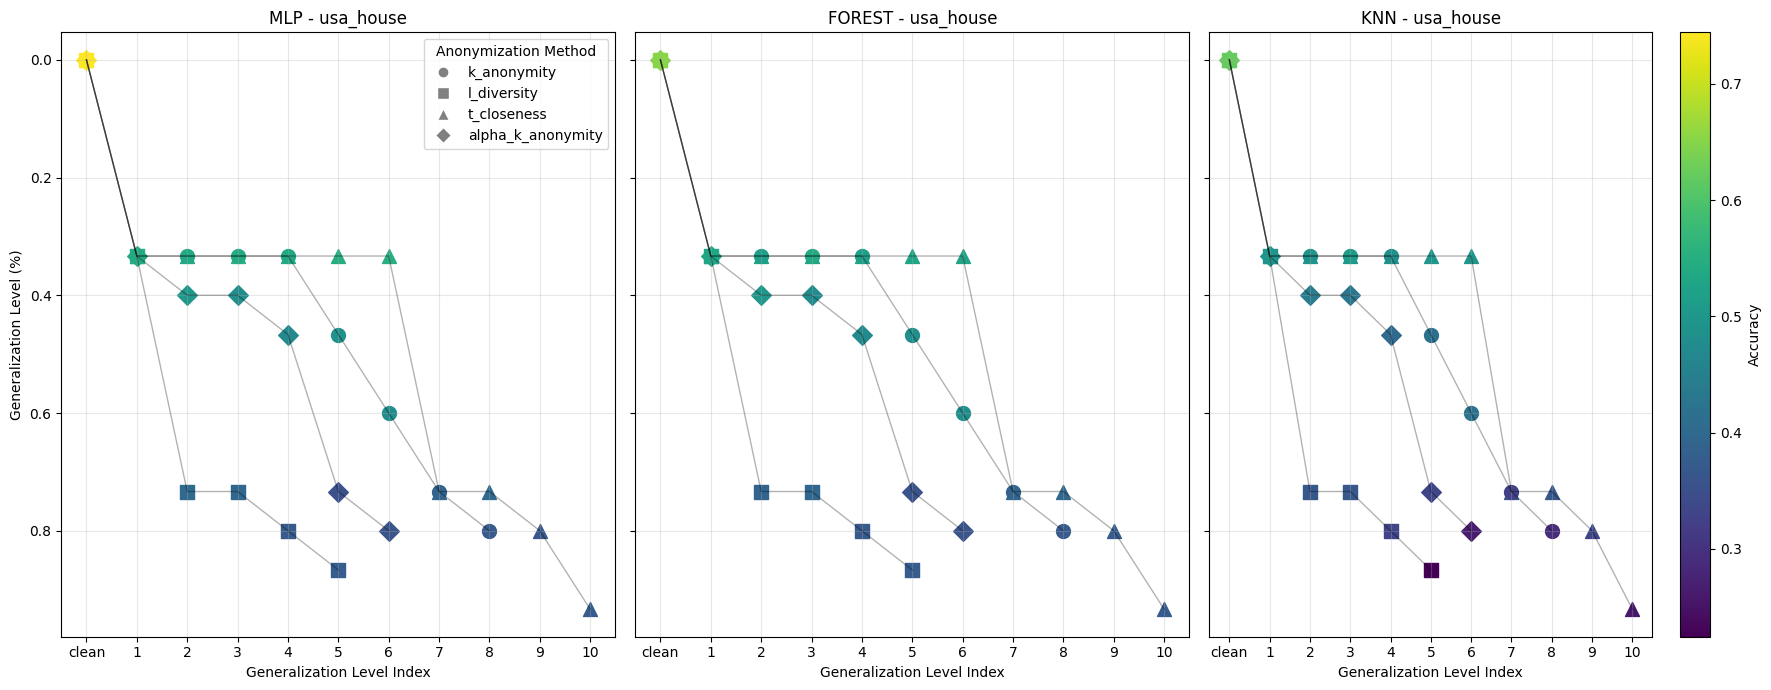

In [4]:
pl.plot_utility("usa_house", ["MLP", "forest", "knn"])

We see here that generally the accuracy falls as the data is more generalized. We also see that k_anonymity and especially t_closeness produces a dataset early that satisfy the increasing values of k and t. Also note, that it is in these that the instability of LIME specially dominates SHAP. This is however only true for MLP. Generally, the performance is affected equally

Let us consider how MLP compares with the other plots, because it looks quite a bit more unstable compared to the other ones

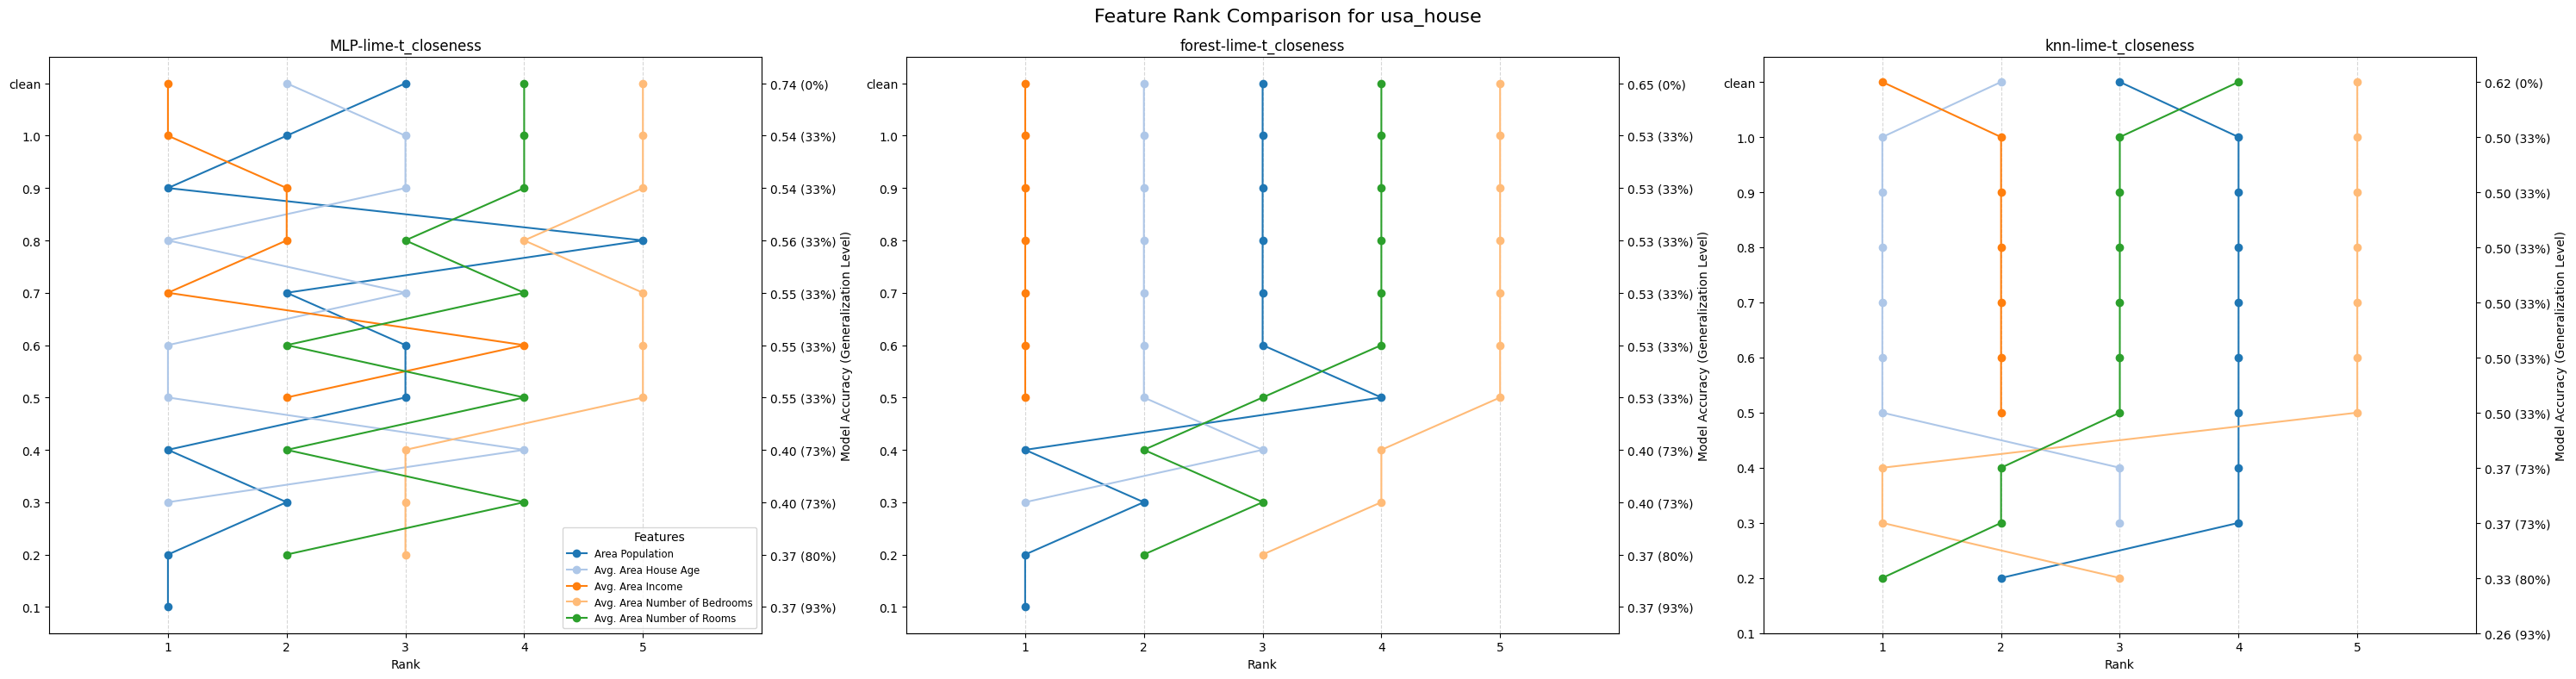

In [4]:
pl.plot_line_compare("usa_house", ["MLP-lime-t_closeness", "forest-lime-t_closeness", "knn-lime-t_closeness"])

As expected, the MLP model is much more unstable. The usa house has between 4000 and 5000 points in it after anonymization, and for each LIME explanation at least 150000 points are used, i.e. all the points are used every time. The fact that the rankings look different probably comes down to the fact that the 1000 representative explanations used are different for every dataset

Let us consider another dataset. Note, this dataset is the only dataset that was allow to suppress 30% of it's instances

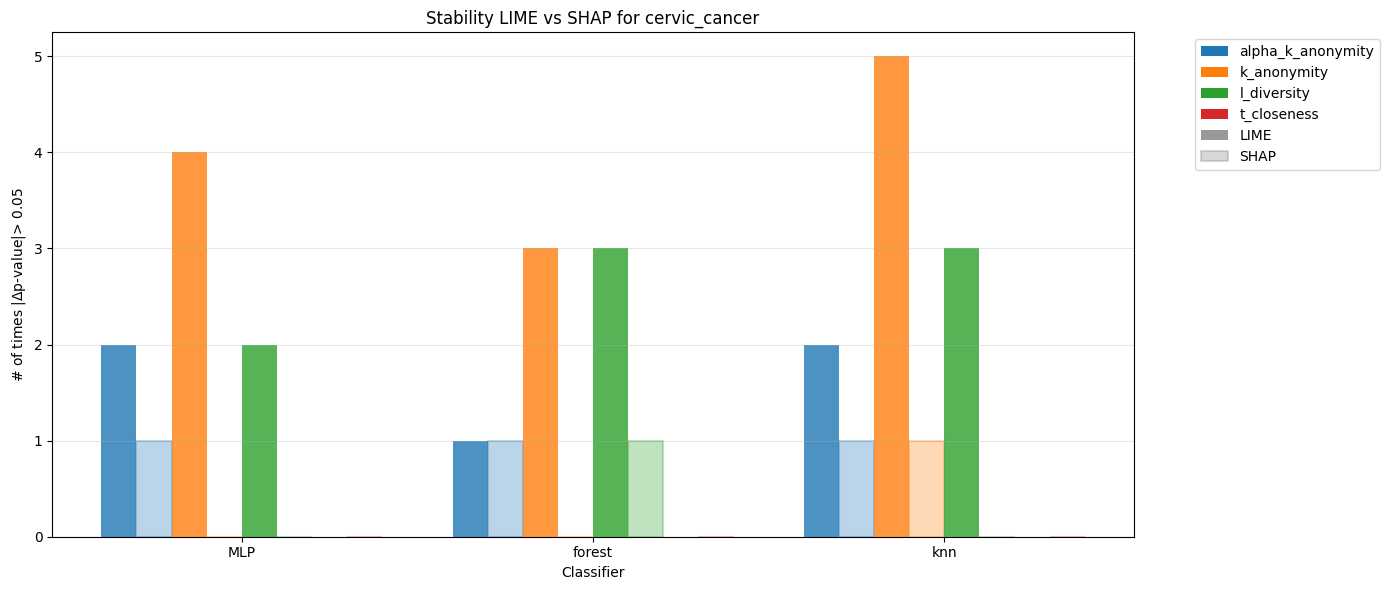

In [11]:
pl.plot_histogram("cervic_cancer", threshold=0.05)

Here it is even more evident. SHAP outperforms LIME in every model. The reason some categories are missing is because the difference is simply not that large at any time. How come?

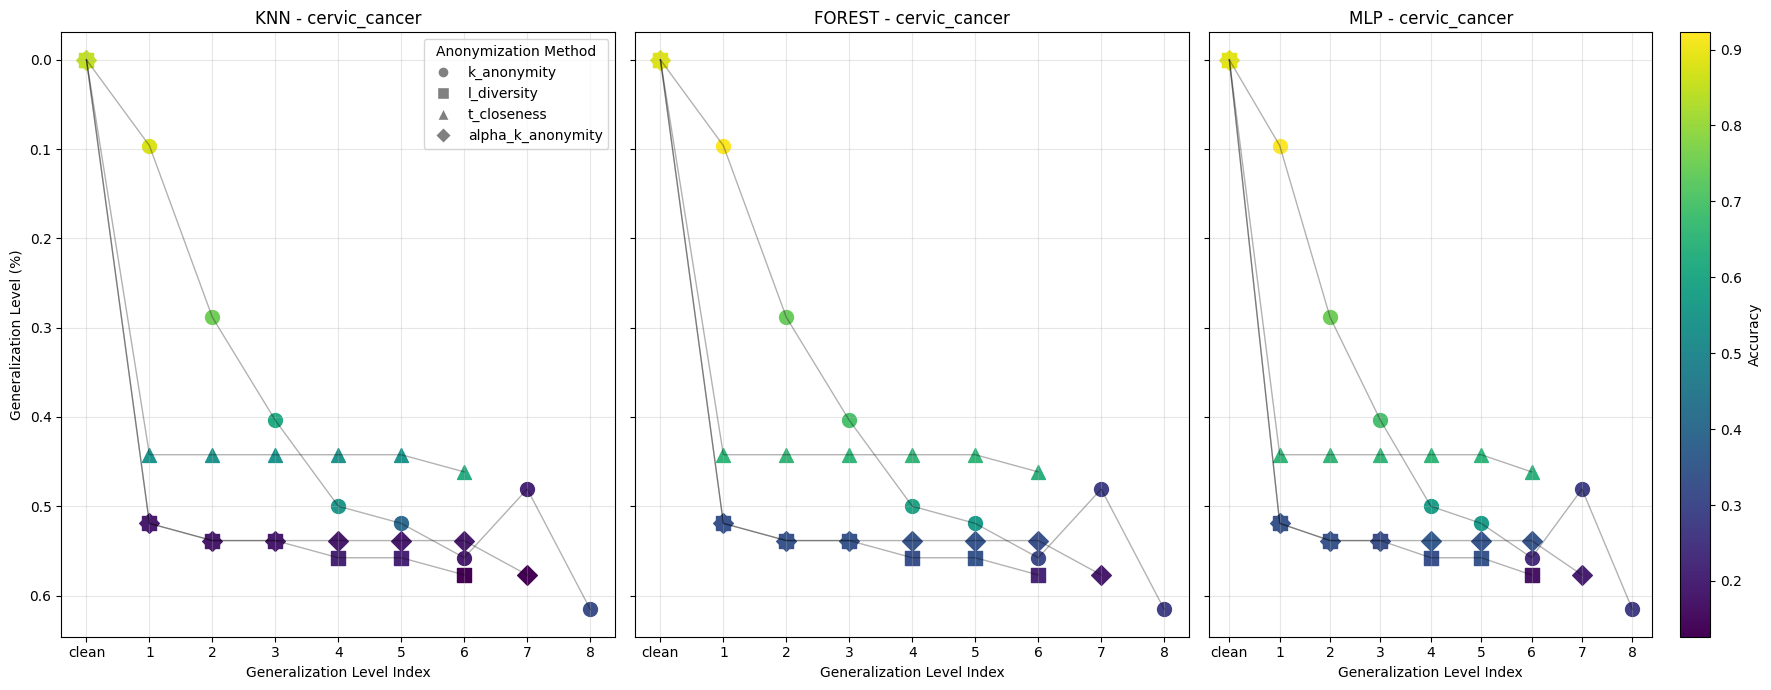

In [5]:
pl.plot_utility("cervic_cancer")

**Note** the weird behavoir at level 7 for k-anonymity. This behavoir stems from the fact that the generalization level is not calculated the right way. There is something wrong with the implementation. Chances are that one of the numbers are treated as a floating point which means that my patch work implementation for floating points messes with things. It is only the generalization level that is a bit messed up, some outlier. The accuracy is still correct.

We see here that the dataset is generalized quickly, further indicating that some anonymization models are more expensive to force onto some datasets. This dataset consists of many binary fearues whcih are anonymized in the order in which they appear in the dataframe.  
**Note** Changing the order of the features to the reverese result in a scenario where most of the datasets cannot be generated, showing that the hiearchy plays a major role

Now let us consider the adult dataset

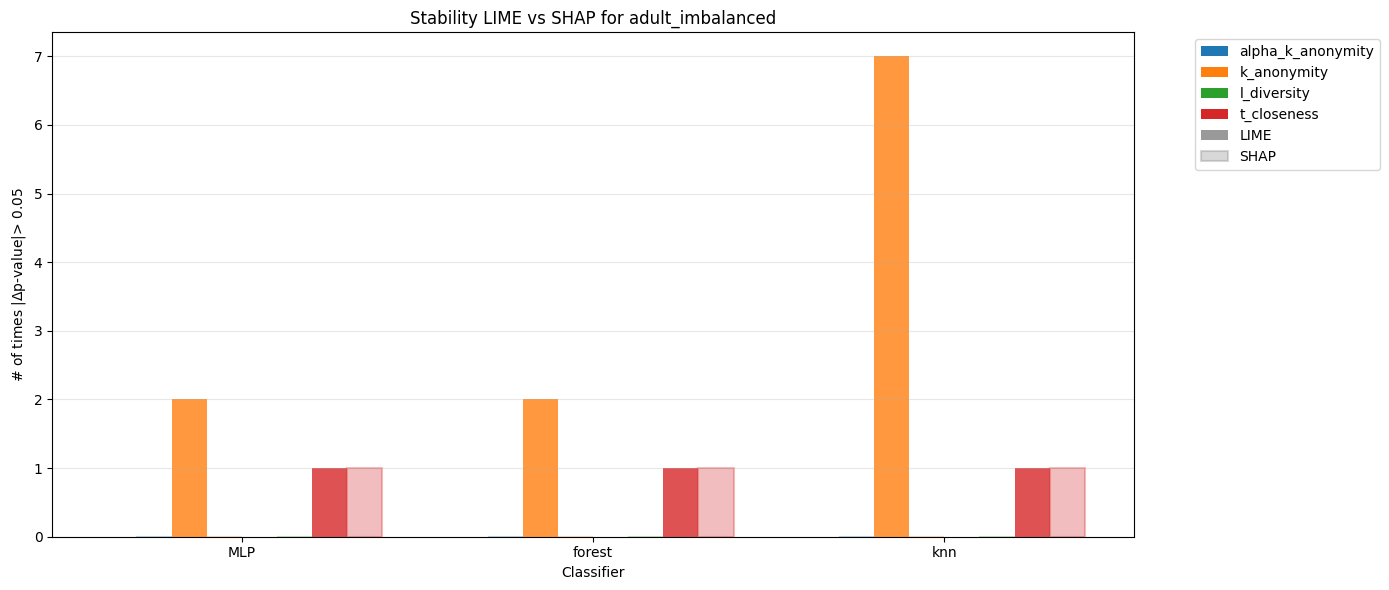

In [6]:
pl.plot_histogram("adult_imbalanced", threshold=0.05)

Now what is up with the lack of boxes? Easy, the Adult dataset is a binary dataset, so l_diversity can only be done once, and apparently it was not possible to make any datasets for $\alpha < 0.9$ so there is nothing to compare to. While this tells a similar story with the few bars it shows, we also se here that MLP seems to be much more stable than knn. That contradicts our previous observation that it was MLP that produced the most unstable results

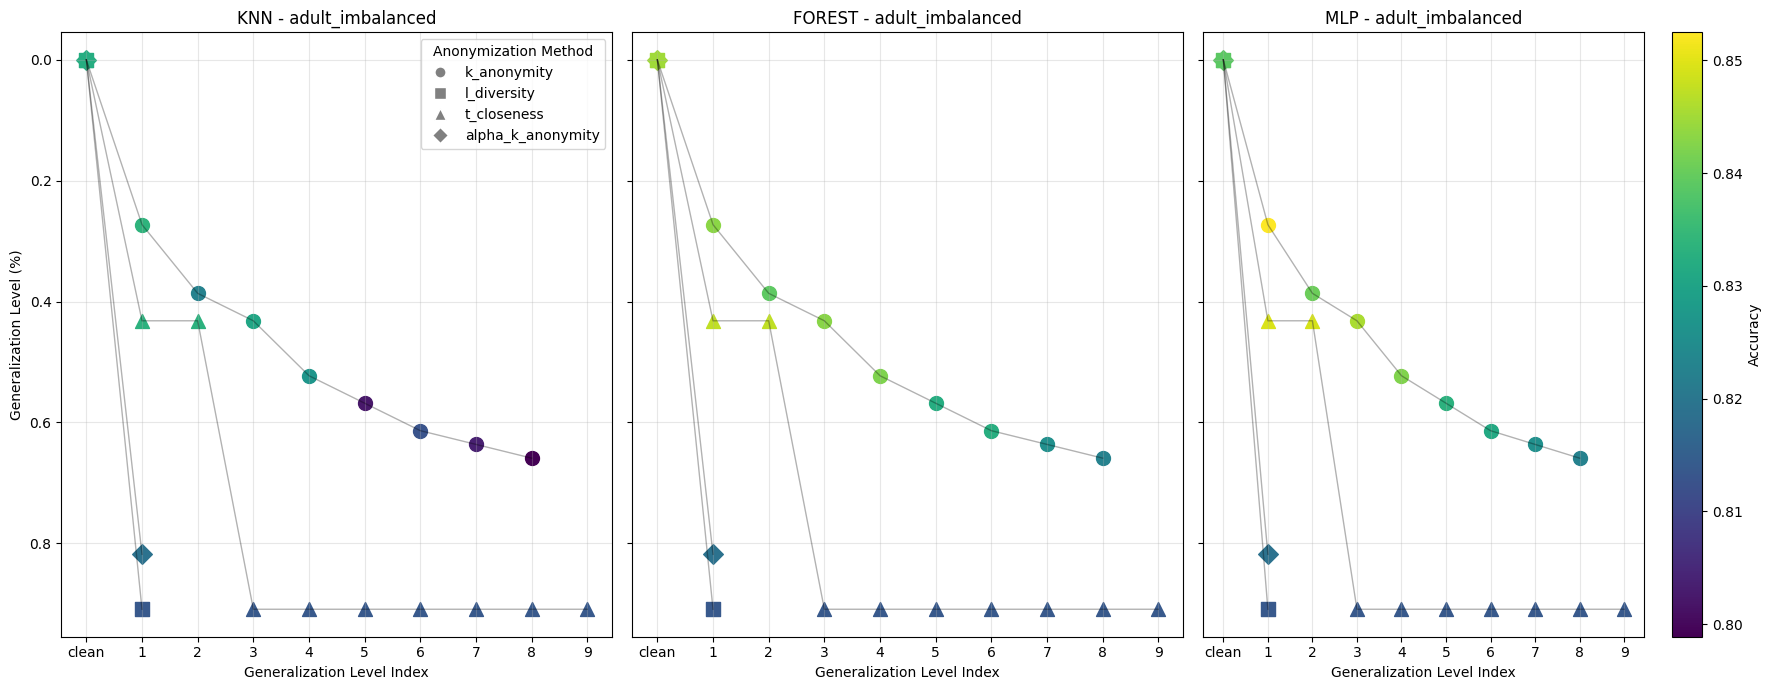

In [7]:
pl.plot_utility("adult_imbalanced")

In [7]:
pd.read_csv("../data/adult/t_closeness/0.9.csv")['income'].value_counts(normalize=True)

income
<=50K    0.816344
>50K     0.183656
Name: proportion, dtype: float64

Here we clearly see a drawback with this generalization method. More instanes associated with a particular target class might be suppressed more than other target classes. If the dataset is already imbalanced, this may result in the furhter imbalanced dataset. Here we see that the models simply guess the majority class all the time, which is why the accuracy is so high all the time. Similarly, this can also explain why the accuracy jumps up and down for forest and MLP. The datasets there might have another distribution compared to the previous ones. 